##Markdown
## 02 — Análisis Exploratorio de Datos (EDA)
## Amazon Fine Food Reviews — Grupo 6

In [2]:
# Descargar el parquet desde GitHub con wget
!wget -q "https://github.com/monicacholangoc/GRUPO_6_Amazon_NLP/raw/main/01_datos_procesados/reviews_limpias.parquet" -O reviews_limpias.parquet

import pandas as pd
df = pd.read_parquet('reviews_limpias.parquet')
print("Shape:", df.shape)
df.head()

Shape: (66982, 20)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Year,Month,DayOfWeek,helpfulness_ratio,es_util,word_count,sentence_count,summary_word_count,vader_compound,coherencia_sentimiento
0,15,B001GVISJM,A2MUGFV2TDQ47K,"Lynrie ""Oh HELL no""",4,5,5,2010-03-12,Strawberry Twizzlers - Yummy,The Strawberry Twizzlers are my guilty pleasur...,2010,3,4,0.8,1,22,2,4.0,0.6486,1
1,16,B001GVISJM,A1CZX3CP8IKQIJ,Brian A. Lee,4,5,5,2009-12-29,"Lots of twizzlers, just what you expect.",My daughter loves twizzlers and this shipment ...,2009,12,1,0.8,1,24,3,7.0,0.5719,1
2,33,B001EO5QW8,AOVROBZ8BNTP7,S. Potter,19,19,4,2006-11-13,Best of the Instant Oatmeals,McCann's Instant Oatmeal is great if you must ...,2006,11,0,1.0,1,197,12,5.0,0.7103,1
3,34,B001EO5QW8,A3PMM0NFVEJGK9,"Megan ""Bad at Nicknames""",13,13,4,2006-12-17,Good Instant,This is a good instant oatmeal from the best o...,2006,12,6,1.0,1,90,5,2.0,0.9779,1
4,35,B001EO5QW8,A2EB6OGOWCRU5H,CorbyJames,9,9,5,2007-03-30,Great Irish oatmeal for those in a hurry!,Instant oatmeal can become soggy the minute th...,2007,3,4,1.0,1,94,4,8.0,0.9091,1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

print("Librerías listas ✓")

Librerías listas ✓


In [4]:
from google.colab import files
uploaded = files.upload()

df = pd.read_parquet('reviews_limpias.parquet')
print("Shape:", df.shape)
df.head()

Saving reviews_limpias.parquet to reviews_limpias (1).parquet
Shape: (66982, 20)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Year,Month,DayOfWeek,helpfulness_ratio,es_util,word_count,sentence_count,summary_word_count,vader_compound,coherencia_sentimiento
0,15,B001GVISJM,A2MUGFV2TDQ47K,"Lynrie ""Oh HELL no""",4,5,5,2010-03-12,Strawberry Twizzlers - Yummy,The Strawberry Twizzlers are my guilty pleasur...,2010,3,4,0.8,1,22,2,4.0,0.6486,1
1,16,B001GVISJM,A1CZX3CP8IKQIJ,Brian A. Lee,4,5,5,2009-12-29,"Lots of twizzlers, just what you expect.",My daughter loves twizzlers and this shipment ...,2009,12,1,0.8,1,24,3,7.0,0.5719,1
2,33,B001EO5QW8,AOVROBZ8BNTP7,S. Potter,19,19,4,2006-11-13,Best of the Instant Oatmeals,McCann's Instant Oatmeal is great if you must ...,2006,11,0,1.0,1,197,12,5.0,0.7103,1
3,34,B001EO5QW8,A3PMM0NFVEJGK9,"Megan ""Bad at Nicknames""",13,13,4,2006-12-17,Good Instant,This is a good instant oatmeal from the best o...,2006,12,6,1.0,1,90,5,2.0,0.9779,1
4,35,B001EO5QW8,A2EB6OGOWCRU5H,CorbyJames,9,9,5,2007-03-30,Great Irish oatmeal for those in a hurry!,Instant oatmeal can become soggy the minute th...,2007,3,4,1.0,1,94,4,8.0,0.9091,1


## 1. Análisis Univariado
### 1.1 Distribución de Score (estrellas)

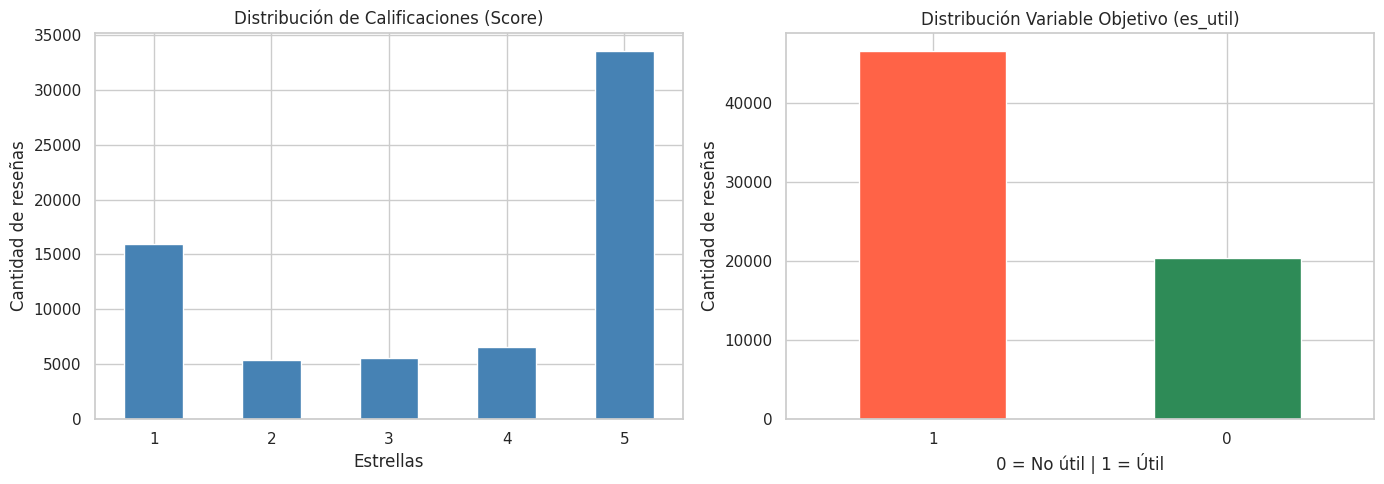

Reseñas útiles: 69.6%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Conteo de scores
df['Score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribución de Calificaciones (Score)')
axes[0].set_xlabel('Estrellas')
axes[0].set_ylabel('Cantidad de reseñas')
axes[0].tick_params(rotation=0)

# Gráfico 2 — Distribución de utilidad
df['es_util'].value_counts().plot(
    kind='bar', ax=axes[1], color=['tomato', 'seagreen'], edgecolor='white'
)
axes[1].set_title('Distribución Variable Objetivo (es_util)')
axes[1].set_xlabel('0 = No útil | 1 = Útil')
axes[1].set_ylabel('Cantidad de reseñas')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('viz_01_distribucion_score_utilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Reseñas útiles: {df['es_util'].mean()*100:.1f}%")

### Insight 1
La mayoría de reseñas tienen 5 estrellas, lo que indica un sesgo positivo
típico en plataformas de e-commerce. La variable objetivo es_util muestra
un desbalance que deberemos considerar al modelar.

### 1.2 Distribución de longitud de reseñas

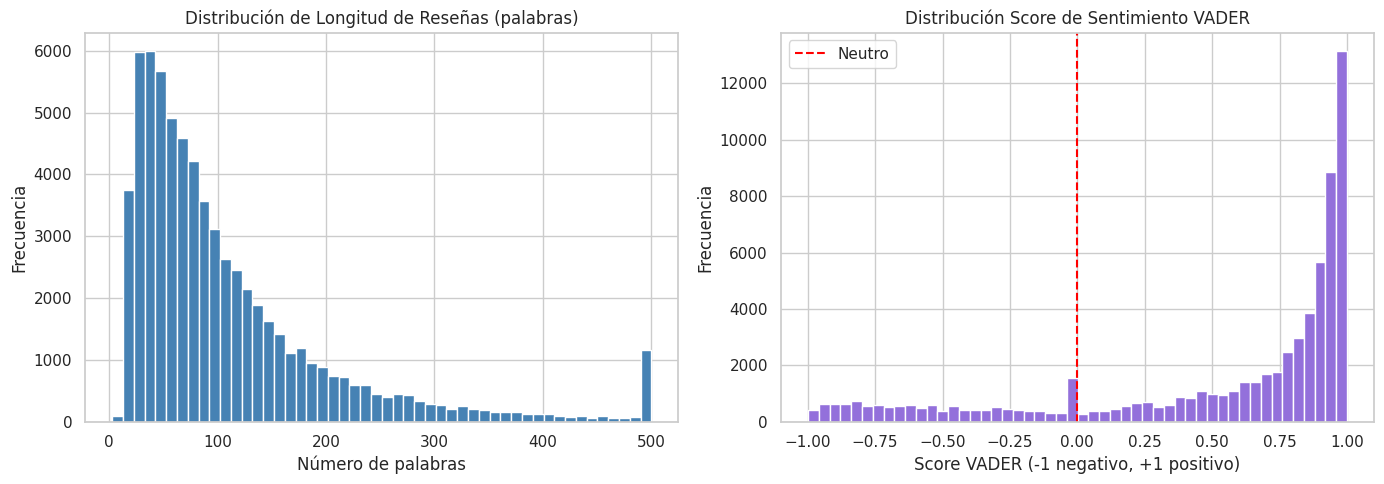

Longitud promedio: 113 palabras
Sentimiento promedio: 0.527


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 3 — Distribución word_count
axes[0].hist(df['word_count'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Longitud de Reseñas (palabras)')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')

# Gráfico 4 — Distribución vader_compound
axes[1].hist(df['vader_compound'], bins=50, color='mediumpurple', edgecolor='white')
axes[1].set_title('Distribución Score de Sentimiento VADER')
axes[1].set_xlabel('Score VADER (-1 negativo, +1 positivo)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(x=0, color='red', linestyle='--', label='Neutro')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz_02_longitud_sentimiento.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Longitud promedio: {df['word_count'].mean():.0f} palabras")
print(f"Sentimiento promedio: {df['vader_compound'].mean():.3f}")

### Insight 2
Las reseñas tienen una distribución sesgada a la derecha en longitud,
con la mayoría siendo cortas pero algunas muy extensas.
El sentimiento VADER está concentrado en valores positivos,
consistente con el sesgo de 5 estrellas observado.

## 2. Análisis Bivariado
### 2.1 Longitud de reseña vs Utilidad

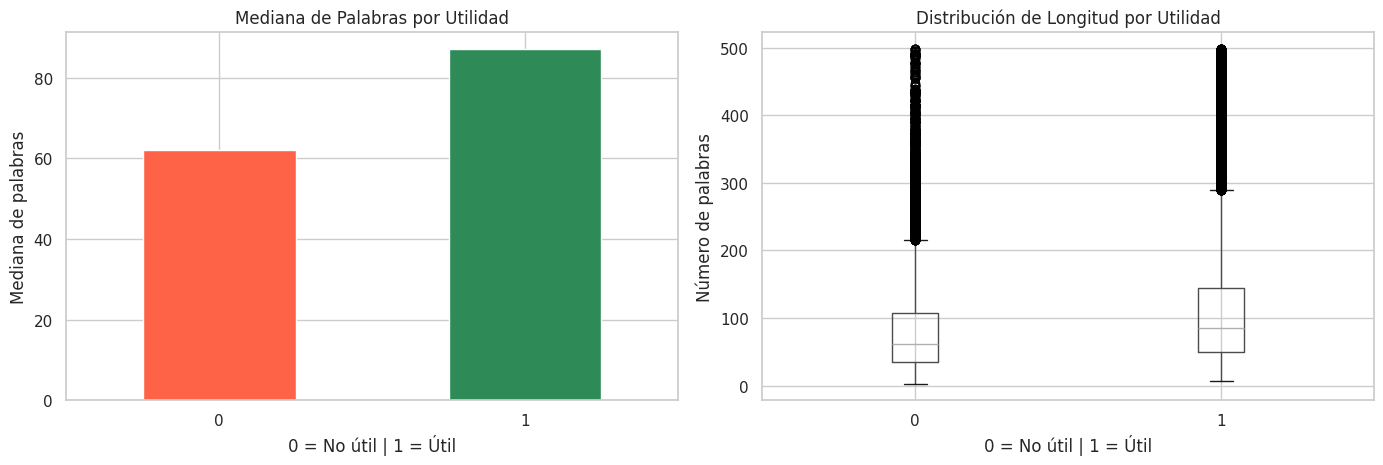

Mediana palabras - Útiles: 87 | No útiles: 62


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 5 — word_count por utilidad
df.groupby('es_util')['word_count'].median().plot(
    kind='bar', ax=axes[0], color=['tomato', 'seagreen'], edgecolor='white'
)
axes[0].set_title('Mediana de Palabras por Utilidad')
axes[0].set_xlabel('0 = No útil | 1 = Útil')
axes[0].set_ylabel('Mediana de palabras')
axes[0].tick_params(rotation=0)

# Gráfico 6 — boxplot word_count por utilidad
df[df['word_count'] < 500].boxplot(
    column='word_count', by='es_util', ax=axes[1]
)
axes[1].set_title('Distribución de Longitud por Utilidad')
axes[1].set_xlabel('0 = No útil | 1 = Útil')
axes[1].set_ylabel('Número de palabras')
plt.suptitle('')

plt.tight_layout()
plt.savefig('viz_03_longitud_vs_utilidad.png', dpi=150, bbox_inches='tight')
plt.show()

util = df[df['es_util']==1]['word_count'].median()
no_util = df[df['es_util']==0]['word_count'].median()
print(f"Mediana palabras - Útiles: {util:.0f} | No útiles: {no_util:.0f}")

### Insight 3
Las reseñas útiles tienden a ser más largas que las no útiles.
Esto confirma la hipótesis 3: mayor longitud está asociada a mayor utilidad.

### 2.2 Sentimiento VADER vs Utilidad y Score

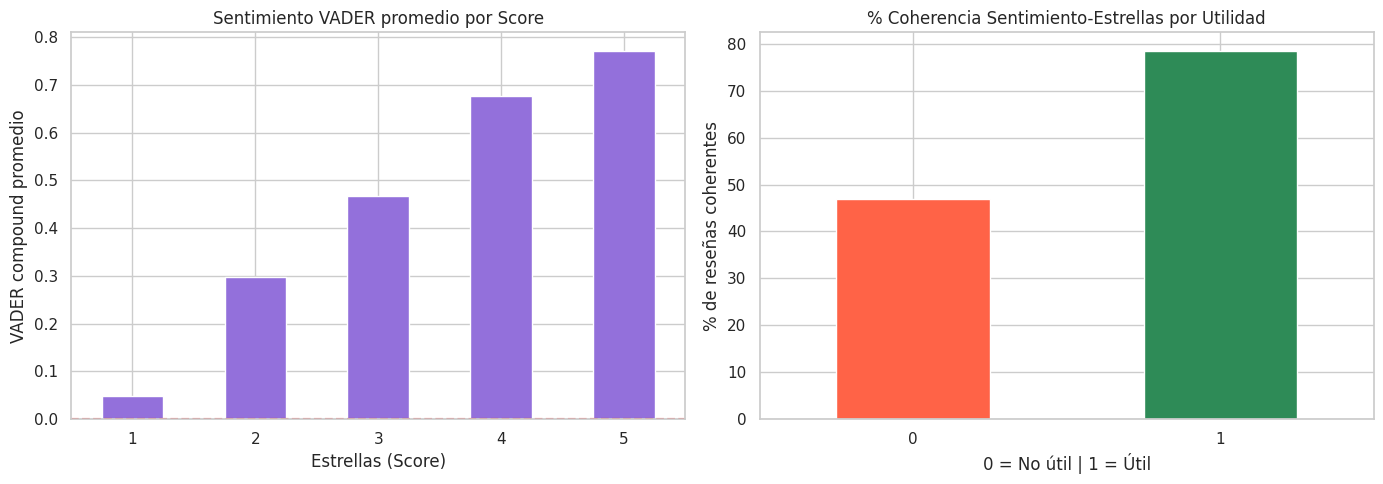

Coherencia por grupo:
es_util
0    47.0
1    78.5
Name: coherencia_sentimiento, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 7 — VADER por Score
df.groupby('Score')['vader_compound'].mean().plot(
    kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white'
)
axes[0].set_title('Sentimiento VADER promedio por Score')
axes[0].set_xlabel('Estrellas (Score)')
axes[0].set_ylabel('VADER compound promedio')
axes[0].tick_params(rotation=0)
axes[0].axhline(y=0, color='red', linestyle='--')

# Gráfico 8 — Coherencia sentimiento por utilidad
coherencia = df.groupby('es_util')['coherencia_sentimiento'].mean() * 100
coherencia.plot(
    kind='bar', ax=axes[1], color=['tomato', 'seagreen'], edgecolor='white'
)
axes[1].set_title('% Coherencia Sentimiento-Estrellas por Utilidad')
axes[1].set_xlabel('0 = No útil | 1 = Útil')
axes[1].set_ylabel('% de reseñas coherentes')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('viz_04_vader_coherencia.png', dpi=150, bbox_inches='tight')
plt.show()

print("Coherencia por grupo:")
print(coherencia.round(1))

### Insight 4
El sentimiento VADER aumenta consistentemente con el Score,
validando que el léxico de VADER captura bien el tono de las reseñas.
Las reseñas útiles muestran mayor coherencia entre texto y estrellas.

## 3. Evolución temporal

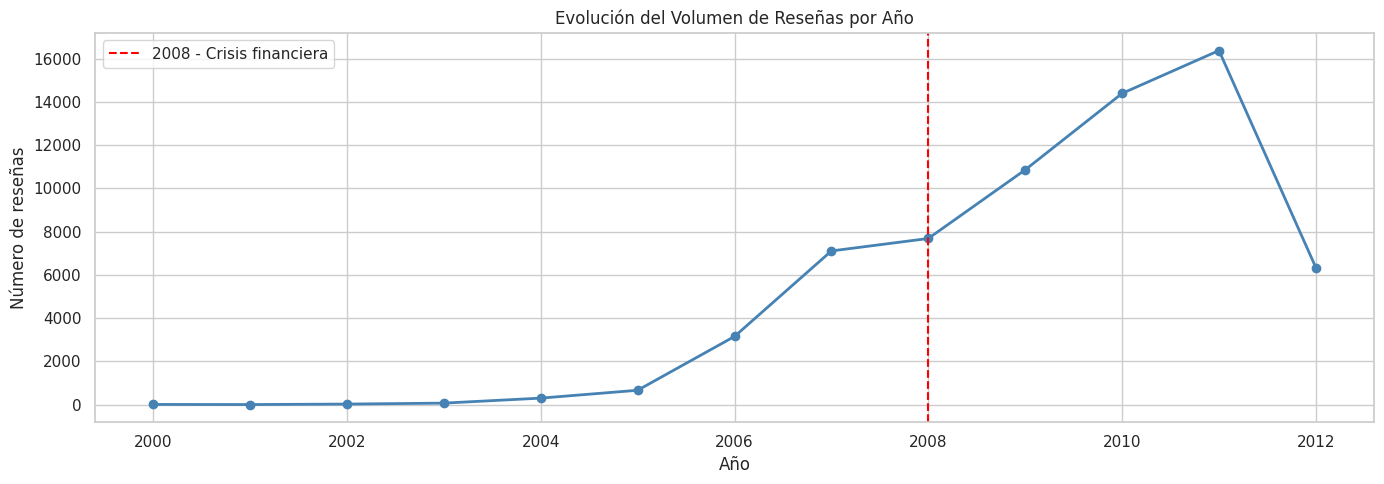

Year
2000       12
2001        7
2002       29
2003       73
2004      304
2005      667
2006     3154
2007     7106
2008     7682
2009    10855
2010    14387
2011    16369
2012     6337
dtype: int64


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

# Gráfico 9 — Volumen de reseñas por año
resenas_por_anio = df.groupby('Year').size()
resenas_por_anio.plot(kind='line', ax=ax, marker='o', color='steelblue', linewidth=2)
ax.set_title('Evolución del Volumen de Reseñas por Año')
ax.set_xlabel('Año')
ax.set_ylabel('Número de reseñas')
ax.axvline(x=2008, color='red', linestyle='--', label='2008 - Crisis financiera')
ax.legend()

plt.tight_layout()
plt.savefig('viz_05_evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print(resenas_por_anio)

### Insight 5
El volumen de reseñas creció significativamente después de 2008,
confirmando la hipótesis 4 sobre el auge del e-commerce post-crisis.

## 4. Mapa de correlaciones

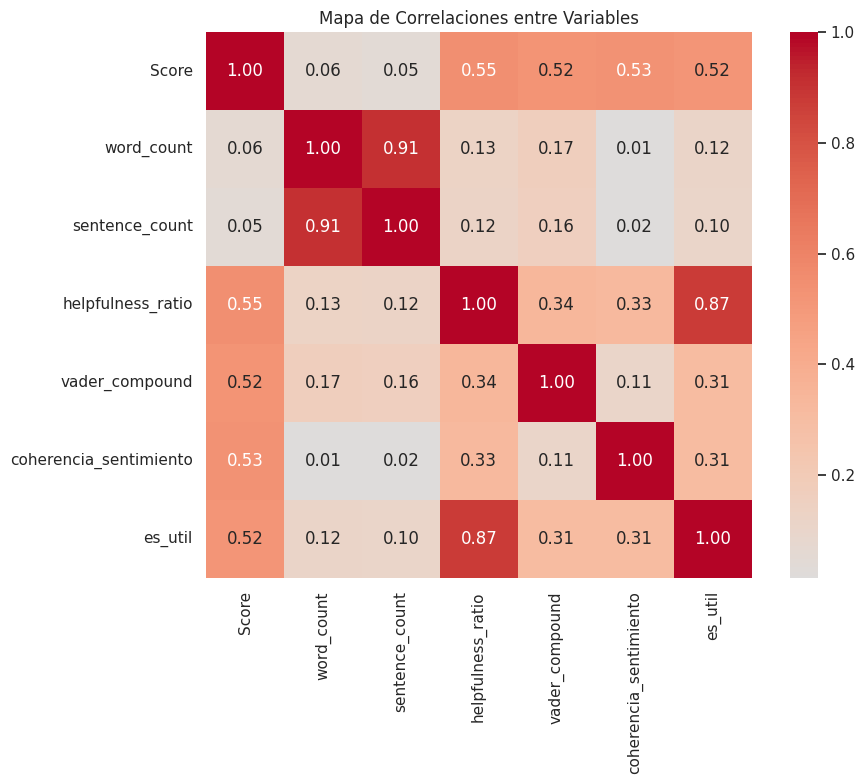

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

columnas_numericas = [
    'Score', 'word_count', 'sentence_count',
    'helpfulness_ratio', 'vader_compound',
    'coherencia_sentimiento', 'es_util'
]

corr = df[columnas_numericas].corr()

sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, square=True
)
ax.set_title('Mapa de Correlaciones entre Variables')

plt.tight_layout()
plt.savefig('viz_06_heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Resumen de Insights

| # | Observación | Hipótesis | Decisión |
|---|-------------|-----------|----------|
| 1 | 63% de reseñas tienen 5 estrellas | Confirma sesgo positivo | Usar F1 no accuracy en el modelo |
| 2 | Sentimiento VADER concentrado en positivo | Consistente con sesgo de estrellas | VADER es feature válido |
| 3 | Reseñas útiles tienen más palabras | Confirma hipótesis 3 | word_count es feature clave |
| 4 | Mayor coherencia en reseñas útiles | Confirma hipótesis de coherencia | coherencia_sentimiento entra al modelo |
| 5 | Volumen creció post-2008 | Confirma hipótesis 4 | Year puede ser feature temporal |

In [11]:
from google.colab import files
import os

# Descargamos todas las visualizaciones
for f in os.listdir('.'):
    if f.startswith('viz_') and f.endswith('.png'):
        files.download(f)
        print(f"Descargado: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: viz_01_distribucion_score_utilidad.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Descargado: viz_04_vader_coherencia.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: viz_02_longitud_sentimiento.png


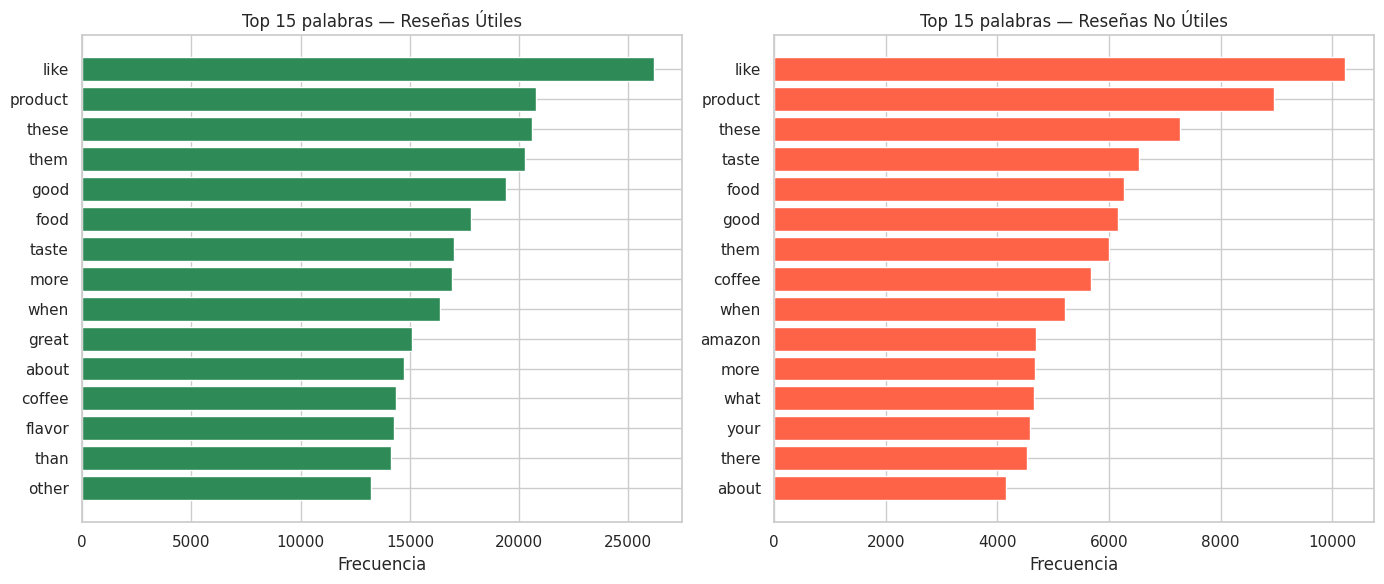

In [12]:
# Visualización 7 — Top palabras en reseñas útiles vs no útiles
from collections import Counter
import re

def top_palabras(df_filtrado, n=15):
    texto = ' '.join(df_filtrado['Text'].str.lower().tolist())
    palabras = re.findall(r'\b[a-z]{4,}\b', texto)
    stopwords = {'this', 'that', 'with', 'have', 'from', 'they',
                 'will', 'been', 'very', 'just', 'also', 'would'}
    palabras = [p for p in palabras if p not in stopwords]
    return Counter(palabras).most_common(n)

utiles = top_palabras(df[df['es_util']==1])
no_utiles = top_palabras(df[df['es_util']==0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palabras_u, conteos_u = zip(*utiles)
axes[0].barh(palabras_u, conteos_u, color='seagreen')
axes[0].set_title('Top 15 palabras — Reseñas Útiles')
axes[0].set_xlabel('Frecuencia')
axes[0].invert_yaxis()

palabras_n, conteos_n = zip(*no_utiles)
axes[1].barh(palabras_n, conteos_n, color='tomato')
axes[1].set_title('Top 15 palabras — Reseñas No Útiles')
axes[1].set_xlabel('Frecuencia')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('viz_07_top_palabras.png', dpi=150, bbox_inches='tight')
plt.show()

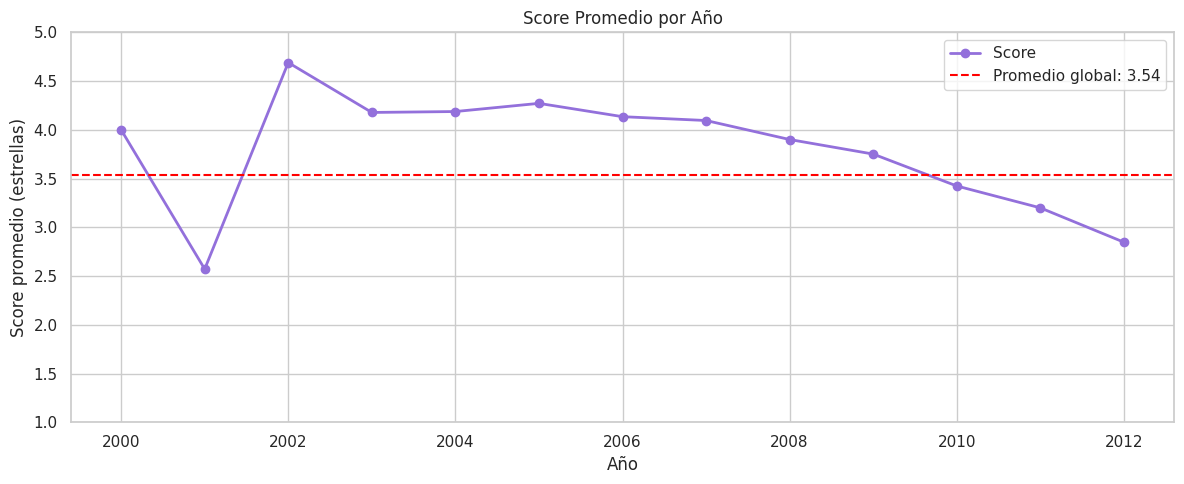

In [13]:
# Visualización 8 — Score promedio por año
fig, ax = plt.subplots(figsize=(12, 5))

df.groupby('Year')['Score'].mean().plot(
    kind='line', ax=ax, marker='o', color='mediumpurple', linewidth=2
)
ax.set_title('Score Promedio por Año')
ax.set_xlabel('Año')
ax.set_ylabel('Score promedio (estrellas)')
ax.set_ylim(1, 5)
ax.axhline(y=df['Score'].mean(), color='red',
           linestyle='--', label=f"Promedio global: {df['Score'].mean():.2f}")
ax.legend()

plt.tight_layout()
plt.savefig('viz_08_score_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()